In [1]:
import pandas as pd
data=pd.read_csv('/content/Air Quality Missing Data.csv')
display(data)

,Date,Ozone,Solar,Wind,Temp
0,01-05-1976,41.0,190.0,7.4,67
1,02-05-1976,36.0,118.0,8.0,72
2,03-05-1976,12.0,149.0,12.6,74
3,04-05-1976,18.0,313.0,11.5,62
4,05-05-1976,NaN,NaN,14.3,56
...,...,...,...,...,...
148,26-09-1976,30.0,193.0,6.9,70
149,27-09-1976,NaN,145.0,13.2,77
150,28-09-1976,14.0,191.0,14.3,75
151,29-09-1976,18.0,131.0,8.0,76


In [16]:
data.duplicated().sum()

np.int64(0)

no duplicate values


In [2]:
data.isnull().sum()

,0
Date,0
Ozone,37
Solar,7
Wind,0
Temp,0


here shows data that about nan values or missing values

Ozone has 37 and Solar has 7 missing values



##Handling missing values

- imputation
- dropping

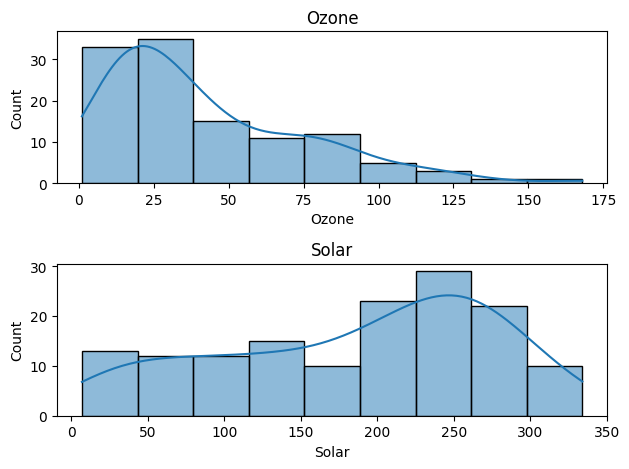

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

 # Added for better visualization
plt.subplot(2,1,1)
sns.histplot(data['Ozone'],kde=True)
plt.title('Ozone')

plt.subplot(2,1,2)
sns.histplot(data['Solar'],kde=True)
plt.title('Solar')

plt.tight_layout()
plt.show()

 Histplot shows that skweness

> Ozone right skewed

> Solar is symmetric







In [14]:
data['Ozone']=data['Ozone'].fillna(data['Ozone'].median())
data['Solar']=data['Solar'].fillna(data['Solar'].mean())

This setp for fill the missing values

> data[Ozone] - skewed - fillna using median

> data[Solar] - almost symmetric filla using mean








In [17]:
data.describe()

,Ozone,Solar,Wind,Temp
count,153.000000,153.000000,153.000000,153.000000
mean,39.558824,185.931507,9.957516,77.882353
std,29.054449,87.960267,3.523001,9.465270
min,1.000000,7.000000,1.700000,56.000000
25%,21.000000,120.000000,7.400000,72.000000
50%,31.500000,194.000000,9.700000,79.000000
75%,46.000000,256.000000,11.500000,85.000000
max,168.000000,334.000000,20.700000,97.000000


In [18]:
box_plot=['Ozone','Solar','Wind','Temp']

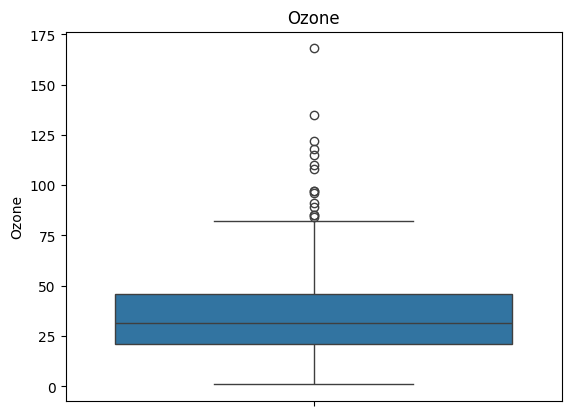

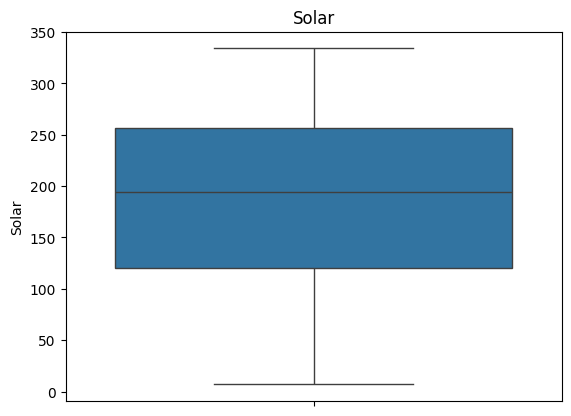

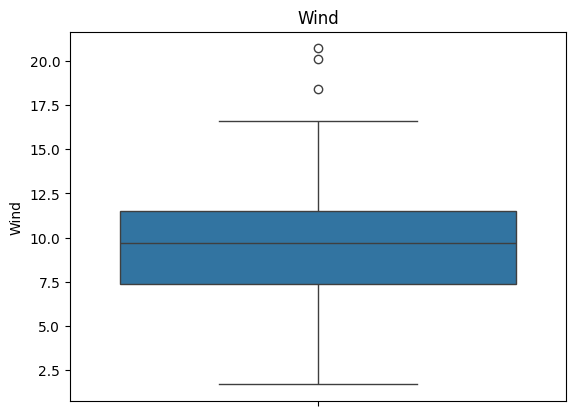

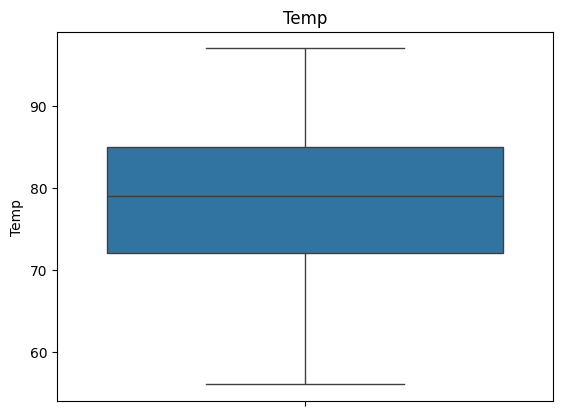

In [19]:
for b in box_plot:
  plt.title(b)
  sns.boxplot(data[b])
  plt.show()

here boxplot helps to see the ouliers.
this is outlier ditection

here Ozone has outlier
Solar has outlier

In [21]:
#outlier_removel of Ozone

Q1 = data['Ozone'].quantile(0.25) #Q1 is lower data 25%
Q3 = data['Ozone'].quantile(0.75) #Q3 is upper data 75%
IQR = Q3 - Q1 #IQR is the middle 50% of data

lower_bound = Q1 - (1.5 * IQR) #lower_bond is Q1-(1.5* inter_quartil_range)
upper_bound = Q3 + (1.5 * IQR) #upper_bond is Q3+(1.5* inter_quartil_range)

cleaned_df = data[(data['Ozone'] >= lower_bound) & (data['Ozone'] <= upper_bound)]
# after removal

cleaned_df

,Date,Ozone,Solar,Wind,Temp
0,01-05-1976,41.0,190.000000,7.4,67
1,02-05-1976,36.0,118.000000,8.0,72
2,03-05-1976,12.0,149.000000,12.6,74
3,04-05-1976,18.0,313.000000,11.5,62
4,05-05-1976,31.5,185.931507,14.3,56
...,...,...,...,...,...
148,26-09-1976,30.0,193.000000,6.9,70
149,27-09-1976,31.5,145.000000,13.2,77
150,28-09-1976,14.0,191.000000,14.3,75
151,29-09-1976,18.0,131.000000,8.0,76


In [23]:
#outlier_removel of Solar

Q1 = data['Solar'].quantile(0.25) #Q1 is lower data 25%
Q3 = data['Solar'].quantile(0.75) #Q3 is upper data 75%
IQR = Q3 - Q1 #IQR is the middle 50% of data

lower_bound = Q1 - (1.5 * IQR) #lower_bond is Q1-(1.5* inter_quartil_range)
upper_bound = Q3 + (1.5 * IQR) #upper_bond is Q3+(1.5* inter_quartil_range)

cleaned_df = data[(data['Solar'] >= lower_bound) & (data['Solar'] <= upper_bound)]
# after removal

cleaned_df

,Date,Ozone,Solar,Wind,Temp
0,01-05-1976,41.0,190.000000,7.4,67
1,02-05-1976,36.0,118.000000,8.0,72
2,03-05-1976,12.0,149.000000,12.6,74
3,04-05-1976,18.0,313.000000,11.5,62
4,05-05-1976,31.5,185.931507,14.3,56
...,...,...,...,...,...
148,26-09-1976,30.0,193.000000,6.9,70
149,27-09-1976,31.5,145.000000,13.2,77
150,28-09-1976,14.0,191.000000,14.3,75
151,29-09-1976,18.0,131.000000,8.0,76
